<a href="https://colab.research.google.com/github/atanilson/Comp702/blob/main/Comp702_Modular.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Libraries

In [ ]:
# Geeting Files from GIt HUB

In [ ]:
"""
from functools import partial
import requests
from pathlib import Path

SCRIPTS_FOLDER = Path("scripts")
SCRIPTS_FOLDER.mkdir(parents=True,
                     exist_ok=True)

# URl of raw file in git hub
get_data_url = "https://raw.githubusercontent.com/atanilson/Comp702/refs/heads/main/scripts/get_data.py"
CNN_Model1_url = "https://raw.githubusercontent.com/atanilson/Comp702/refs/heads/main/scripts/CNN_Model1.py"
data_setup_url = "https://raw.githubusercontent.com/atanilson/Comp702/refs/heads/main/scripts/data_setup.py"
engine_url = "https://raw.githubusercontent.com/atanilson/Comp702/refs/heads/main/scripts/engine.py"
Main_script_url = "https://raw.githubusercontent.com/atanilson/Comp702/refs/heads/main/scripts/Main_script.py"
utils_url = "https://raw.githubusercontent.com/atanilson/Comp702/refs/heads/main/scripts/utils.py"

request = requests.get(get_data_url)
with open("scripts/get_data.py","wb") as f:
  f.write(request.content)
"""

In [2]:
%%capture
!mkdir scripts
!wget https://raw.githubusercontent.com/atanilson/Comp702/refs/heads/main/scripts/get_data.py
!wget https://raw.githubusercontent.com/atanilson/Comp702/refs/heads/main/scripts/CNN_Model1.py
!wget https://raw.githubusercontent.com/atanilson/Comp702/refs/heads/main/scripts/data_setup.py
!wget https://raw.githubusercontent.com/atanilson/Comp702/refs/heads/main/scripts/engine.py
!wget https://raw.githubusercontent.com/atanilson/Comp702/refs/heads/main/scripts/Main_script.py
!wget https://raw.githubusercontent.com/atanilson/Comp702/refs/heads/main/scripts/utils.py
!mv get_data.py CNN_Model1.py data_setup.py engine.py Main_script.py utils.py scripts/
#!unzip scripts.zip

In [3]:
import os
import torch
from scripts import data_setup, engine, utils, get_data
from timeit import default_timer as timer

from torchvision import transforms

device = "cuda" if torch.cuda.is_available() else "cpu"

In [4]:
device

'cuda'

In [5]:
#!nvidia-smi

In [6]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [7]:
get_data.download()

In [ ]:
#!rm -r "data/EuroSAT_RGB/River"

In [ ]:
#!rm -r "data/EuroSAT_RGB/SeaLake"

In [14]:
# Setup hyperparameters
NUM_EPOCHS = 150
BATCH_SIZE = 32
TEST_SPLIT = 0.2
HIDDEN_UNITS = 10
LEARNING_RATE = 0.001

# Setup directories
data_dir = "data/EuroSAT_RGB"

size_cut = 64

# Create tranforms Train
transform_train = transforms.Compose([
    transforms.Resize(size_cut),
    transforms.RandomResizedCrop(size_cut),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    #transforms.RandomHorizontalFlip(),
    #****transforms.RandomRotation(10),
    #transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create tranforms test
transform_test = transforms.Compose([
    transforms.Resize(size_cut),
    transforms.CenterCrop(size_cut),
    #transforms.RandomHorizontalFlip(),
    #****transforms.RandomRotation(10),
    #transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


## Test transform onlr resise and normilize


# Create dataloaders
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders2(dataset_dir="data/EuroSAT_RGB",
                                                                               train_transform=transform_train,
                                                                               test_transform=transform_test,
                                                                               batch_size=BATCH_SIZE,
                                                                               test_split = TEST_SPLIT,
                                                                               #random_seed = 42,
                                                                               #num_workers = 1
                                                                               )

In [ ]:
class_names

['AnnualCrop',
 'Forest',
 'HerbaceousVegetation',
 'Highway',
 'Industrial',
 'Pasture',
 'PermanentCrop',
 'Residential',
 'River']

In [15]:
## MODEL

###model = - instatiate wterever
from torchvision.models import resnet50, ResNet50_Weights
from scripts import CNN_Model1
"""
#model_2 = resnet50(weights=ResNet50_Weights.DEFAULT)
model_2 = resnet50(weights=None)
model_2.fc = torch.nn.Linear(in_features=model_2.fc.in_features, out_features=len(class_names))
model_2 = model_2.to(device)

"""
model_1 = CNN_Model1.CNN_Model1(
    input_shape=3,
    hidden_units=10,
    output_shape=len(class_names)
).to(device)


In [16]:
## LOSS FUNCTION OPTMIZER
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_1.parameters(), lr=LEARNING_RATE)

start_time = timer()
trained_model, results = engine.train(model=model_1, #Change to train next time I will change on the script
             train_dataloader = train_dataloader,
             test_dataloader = test_dataloader,
             loss_fn = loss_fn,
             optimizer = optimizer,
             epochs = NUM_EPOCHS,
             device=device)
end_time = timer()

time_taken = end_time-start_time

print(f"Total training time:{end_time-start_time:.3f} seconds")

  0%|          | 0/150 [00:00<?, ?it/s]

Epoch: 0 | Train loss: 2.2896, Train Acc: 11.0556% | Test loss:2.2717, Test acc: 10.7803%
Epoch: 1 | Train loss: 2.2240, Train Acc: 12.2824% | Test loss:2.1917, Test acc: 15.1257%
Epoch: 2 | Train loss: 2.1243, Train Acc: 17.6296% | Test loss:2.0704, Test acc: 20.7902%
Epoch: 3 | Train loss: 2.0055, Train Acc: 22.4722% | Test loss:1.9620, Test acc: 22.8920%
Epoch: 4 | Train loss: 1.9390, Train Acc: 23.4722% | Test loss:1.9107, Test acc: 24.1679%
Epoch: 5 | Train loss: 1.8975, Train Acc: 23.6065% | Test loss:1.8632, Test acc: 24.4576%
Epoch: 6 | Train loss: 1.8523, Train Acc: 24.4167% | Test loss:1.8250, Test acc: 25.1726%
Epoch: 7 | Train loss: 1.8229, Train Acc: 25.4352% | Test loss:1.7864, Test acc: 26.5163%
Epoch: 8 | Train loss: 1.7985, Train Acc: 27.0324% | Test loss:1.7714, Test acc: 26.7382%
Epoch: 9 | Train loss: 1.7734, Train Acc: 29.0833% | Test loss:1.7279, Test acc: 29.8570%
Epoch: 10 | Train loss: 1.7381, Train Acc: 30.8796% | Test loss:1.6765, Test acc: 33.3210%
Epoch: 11

In [ ]:
type(trained_model)

scripts.CNN_Model1.CNN_Model1

In [11]:
save_dir = "./drive/My Drive/Colab Notebooks/Comp702/Models/Retrained"

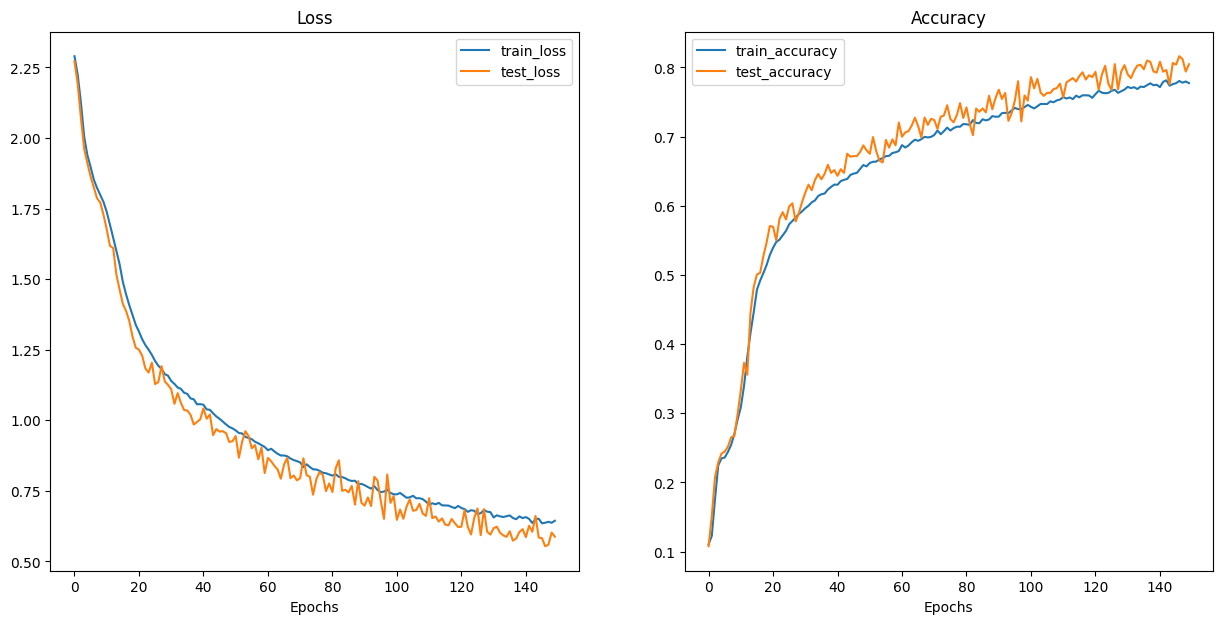

In [17]:
utils.plot_loss_curves(results)

In [18]:
#
utils.save_model(model=trained_model,
                 target_dir = save_dir,
                 model_name="MODEL1_0001_SDG-RGB_B32_WW_EP150_S64_NAug.pth")

#
utils.save_results(results=results,
                   optimizer="SDG",
                   lr="0_001",
                   model="MODEL1_RGB_B32_WW_EP150_S64_NAug",
                   time=time_taken,
                   save_dir=save_dir)

[INFO] Saving model to: drive/My Drive/Colab Notebooks/Comp702/Models/Retrained/MODEL1_0001_SDG-RGB_B32_WW_EP150_S64_NAug.pth
Saving to ./drive/My Drive/Colab Notebooks/Comp702/Models/RetrainedMODEL1_RGB_B32_WW_EP150_S64_NAug_SDG_0_001.csv


In [ ]:
#
utils.save_results(results=results,
                   optimizer="ADAMmmmm",
                   lr="0_001",
                   model="MODEL_1_RGB",
                   time=time_taken,
                   save_dir=save_dir)